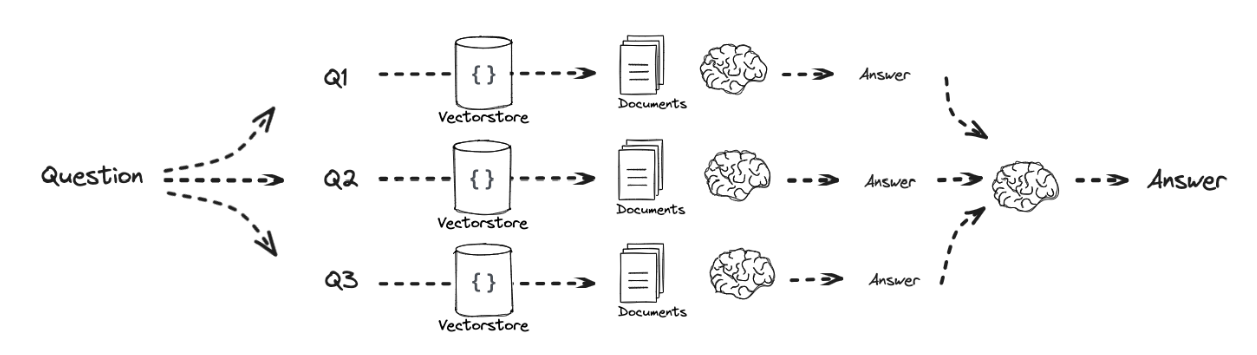

In [1]:
import bs4
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ADV_RAG_KEY")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
blog_docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits, "", len(splits)

([Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and ref

In [3]:
vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"))

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)
retriever 

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002656FDD8290>, search_type='mmr', search_kwargs={'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5})

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=api_key)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x00000265704D5ED0>, default_metadata=(), model_kwargs={})

In [5]:
decomposition_prompt = ChatPromptTemplate.from_template("""
Break the following question into 3 sub-questions that can be answered in isolation.

Question:
{question}

Return only the questions separated by newlines.
""")

generate_subquestions = (
    decomposition_prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(
        lambda x: x.split("\n")
    )
)

In [6]:
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_subquestions.invoke({"question":question})
questions

['1.  What is the primary function of the Large Language Model (LLM) within an autonomous agent system?',
 '2.  What are the core architectural modules that constitute an autonomous agent system?',
 '3.  What components enable an LLM-powered agent to achieve autonomy and interact with its environment?']

In [7]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [8]:
rag_prompt = ChatPromptTemplate.from_template("""
Answer the question using ONLY the context below.

Context:
{context}

Question:
{question}
""")


def answer_subquestion(sub_question):
    docs = retriever.invoke(sub_question)
    context = format_docs(docs)

    chain = (
        rag_prompt
        | llm
        | StrOutputParser()
    )

    answer = chain.invoke({
        "context": context,
        "question": sub_question,
    })

    return {
        "question": sub_question,
        "answer": answer,
    }

In [9]:
decomposition_rag_chain = (generate_subquestions | 
                           RunnableLambda(lambda questions: [answer_subquestion(q) for q in questions]))

In [10]:
results = decomposition_rag_chain.invoke({
    "question": question
})

results

[{'question': '1.  What is the primary function of the Large Language Model (LLM) within an autonomous agent system?',
  'answer': "Within an autonomous agent system, the Large Language Model (LLM) functions as the agent's brain and its core controller. It also works as a router to route inquiries to the best suitable expert module in a MRKL system."},
 {'question': '2.  What are the core architectural modules that constitute an autonomous agent system?',
  'answer': 'Based on the context, the core architectural modules that constitute an autonomous agent system are:\n\n*   **LLM (Large Language Model):** The system is described as an "LLM-powered autonomous agent system," indicating the LLM is a central component.\n*   **Tool use:** The agent learns to call external APIs for extra information, which is presented as a distinct capability/module.\n*   **Memory:** Explicitly labeled as "Component Two," providing the capability to retain and recall information.'},
 {'question': '3.  What 

In [11]:
def format_qa_pairs(results):

    return "\n\n".join([ f"Question: {r['question']} \n Answer: {r['answer']}" for r in results])

In [ ]:
synthesis_prompt = ChatPromptTemplate.from_template("""
You are given a set of question-answer pairs.

Use them to answer the original question.

Q&A Pairs:
{context}

Original Question:
{question}
""")

final_chain = (
    RunnableParallel({
        "context": (decomposition_rag_chain | RunnableLambda(format_qa_pairs)),
        "question": RunnablePassthrough(),
    })
    | synthesis_prompt
    | llm
    | StrOutputParser()
)

In [19]:
response = final_chain.invoke(question)

print(response)

Based on the provided Q&A pairs, the main components of an LLM-powered autonomous agent system are:

*   **LLM (Large Language Model):** This functions as the agent's brain and core controller, and can also act as a router.
*   **Tool use:** This enables the agent to call external APIs for additional information (such as current information, code execution capability, and access to proprietary information sources) that is not present in its model weights.
*   **Memory:** This includes both short-term memory (for in-context learning) and long-term memory (for retaining and recalling information over extended periods, often leveraging an external vector store).
